# Stage 1 — EDA da base Bank Marketing

**Datathon 7MLET — Grupo 74.** Notebook reprodutível de Análise Exploratória sobre a base processada (sem vazamento).

> Roda offline com o *facsimile* determinístico ou com a base Kaggle real (se baixada — ver `data/kaggle/README.md`).

In [1]:
import sys; sys.path.insert(0, "../src")
import pandas as pd, matplotlib.pyplot as plt
from adaptive_offers.data.preprocessing import build_processed, load_processed
from adaptive_offers.data.quality import quality_report, target_rate_by
pd.set_option("display.width", 120)

## 1. Carregar / construir a base processada
O build registra proveniência (fonte, versão, licença) em `data/processed/provenance.json`.

In [2]:
df, prov, path = build_processed(n_rows=20000)
print("source:", prov.source, "| version:", prov.version, "| license:", prov.license)
df.head()

2026-08-15 18:10:20,753 | INFO    | adaptive_offers.data.loader | {"event": "load_real", "path": "C:\\Users\\Dione\\Desktop\\datathon-7mlet-grupo-74\\datathon-7mlet-grupo-64\\data\\kaggle\\raw\\bank-additional-full.csv"}


2026-08-15 18:10:21,121 | INFO    | adaptive_offers.data.preprocessing | {"event": "processed_built", "ts": "2026-08-15T21:10:21.121979+00:00", "source": "real", "rows": 41188, "cols": 22, "target_rate": 0.1127, "dropped_leakage": ["duration"], "path": "C:\\Users\\Dione\\Desktop\\datathon-7mlet-grupo-74\\datathon-7mlet-grupo-64\\data\\processed\\bank_marketing_processed.parquet"}


source: real | version: UCI bank-additional-full (2014) | license: CC BY 4.0 (UCI Machine Learning Repository / Moro et al., 2014)


,client_event_id,age,job,marital,education,default,housing,loan,contact,month,...,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,previously_contacted,pdays_since,subscribed
0,ce_0000000,56,housemaid,married,basic.4y,no,no,no,telephone,may,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
1,ce_0000001,57,services,married,high.school,unknown,no,no,telephone,may,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
2,ce_0000002,37,services,married,high.school,no,yes,no,telephone,may,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
3,ce_0000003,40,admin.,married,basic.6y,no,no,no,telephone,may,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
4,ce_0000004,56,services,married,high.school,no,no,yes,telephone,may,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0


## 2. Perfil de qualidade
Missingness, cardinalidade, duplicatas e balanceamento do alvo.

In [3]:
rep = quality_report(df)
print("rows:", rep["n_rows"], "cols:", rep["n_cols"], "duplicates:", rep["n_duplicates"])
print("target:", rep["target"])

rows: 41188 cols: 22 duplicates: 0
target: {'name': 'subscribed', 'positive_rate': 0.1127, 'imbalance_ratio': 7.88}


## 3. Balanceamento do alvo `subscribed`
O forte desbalanceamento justifica métricas além de acurácia (uplift/regret) na Etapa 4.

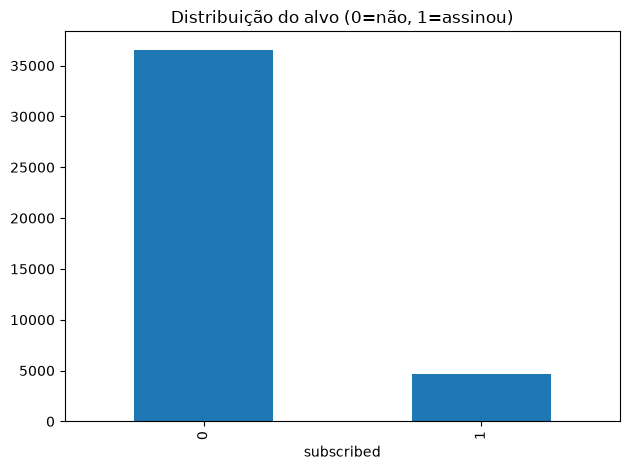

In [4]:
ax = df["subscribed"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Distribuição do alvo (0=não, 1=assinou)"); ax.set_xlabel("subscribed"); plt.tight_layout(); plt.show()

## 4. Drivers de conversão
Taxa de assinatura por `poutcome` e por `contact` — sinais que alimentam o contexto do bandit (Etapa 3).

In [5]:
print(target_rate_by(df, "poutcome").to_string())
print()
print(target_rate_by(df, "contact").to_string())

             subscription_rate      n
poutcome                             
success                 0.6511   1373
failure                 0.1423   4252
nonexistent             0.0883  35563

           subscription_rate      n
contact                            
cellular              0.1474  26144
telephone             0.0523  15044


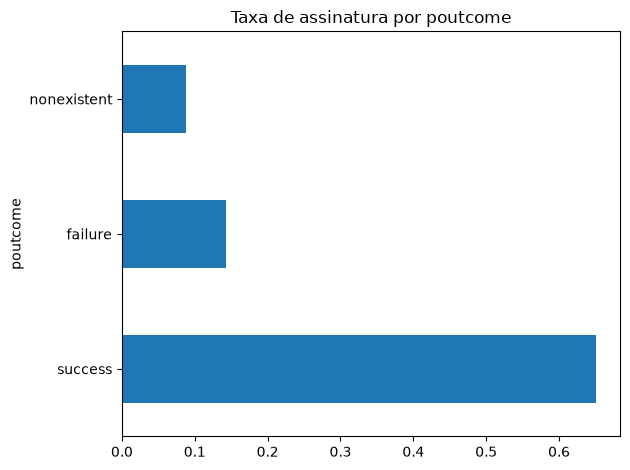

In [6]:
g = target_rate_by(df, "poutcome")
ax = g["subscription_rate"].plot(kind="barh")
ax.set_title("Taxa de assinatura por poutcome"); plt.tight_layout(); plt.show()

## 5. Idade vs. conversão
Clientes nos extremos etários (estudantes/aposentados) tendem a converter mais.

In [7]:
df["age_band"] = pd.cut(df["age"], bins=[17,25,35,45,55,65,100], labels=["18-25","26-35","36-45","46-55","56-65","65+"])
print(target_rate_by(df, "age_band").to_string())

          subscription_rate      n
age_band                          
65+                  0.4685    619
18-25                0.2089   1661
56-65                0.1522   2963
26-35                0.1172  14847
46-55                0.0869   8249
36-45                0.0851  12844


C:\Users\Dione\Desktop\datathon-7mlet-grupo-74\datathon-7mlet-grupo-64\notebooks\../src\adaptive_offers\data\quality.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(by)[target].agg(["mean", "count"]).rename(


## 6. Conclusões
- Sem vazamento (`duration` removida; `pdays` tratado).
- Alvo desbalanceado (~5% facsimile / ~11% real).
- Drivers: `poutcome=success`, canal `cellular`, juros baixos, extremos etários.
- Esses sinais definem o **vetor de contexto** usado pelo LinUCB na decisão de oferta.

Ver `reports/eda-quality-report.md` para o relatório consolidado.